In [5]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict
load_dotenv()

True

In [ ]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    
)
prompt="hello how are you"
llm.invoke(prompt).content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [12]:
class llm_state(TypedDict):
    question:str
    answer:str

In [ ]:
def model_qa(state: llm_state)->llm_state:
    question=state['question']
    prompt=f"answere the following {question}"
    answer=llm.invoke(prompt).content
    state['answer']=answer
    return state



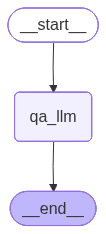

In [16]:
graph=StateGraph(llm_state)
graph.add_node("qa_llm",model_qa)

graph.add_edge(START,"qa_llm")
graph.add_edge("qa_llm",END)

graph.compile()

In [18]:

workflow=graph.compile()

In [ ]:
prompt={"question":"hello"}
workflow.invoke(prompt)

{'question': 'hello', 'answer': 'Hello, how can I assist you today?'}